In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

METHODS = ['SemiBin2', 'MetaDecoder', 'LorBin', 'ComeBin']
MEDIUM_COMP, MEDIUM_CONT = 50, 10
HIGH_COMP, HIGH_CONT = 90, 5

c:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
all_bins = pd.read_csv('../pre-calculated_data/urban_soil_bin_quality.csv')
required = ['Sample', 'Method', 'Completeness', 'Contamination']
for metric in ['Completeness', 'Contamination']:
    all_bins[metric] = pd.to_numeric(all_bins[metric], errors='raise')

In [3]:
coverage = pd.crosstab(all_bins['Sample'], all_bins['Method'])
all4_samples = sorted(coverage.index)
all_bins['Method'] = pd.Categorical(all_bins['Method'], categories=METHODS, ordered=True)
all_bins['Bin_ID'] = np.arange(len(all_bins))
print(f'{len(all4_samples)} samples; {len(all_bins):,} bins')
display(all_bins.head())

57 samples; 420,103 bins


,Sample,Method,Completeness,Contamination,Bin_ID
0,cpsnj01,SemiBin2,99.97,0.22,0
1,cpsnj01,SemiBin2,100.00,0.54,1
2,cpsnj01,SemiBin2,91.13,2.78,2
3,cpsnj01,SemiBin2,37.87,0.88,3
4,cpsnj01,SemiBin2,4.22,0.32,4


In [4]:
all_bins['Medium_or_better'] = (
    (all_bins['Completeness'] > MEDIUM_COMP)
    & (all_bins['Contamination'] < MEDIUM_CONT)
)
all_bins['High_quality'] = (
    (all_bins['Completeness'] > HIGH_COMP)
    & (all_bins['Contamination'] < HIGH_CONT)
)

In [5]:
def summarize_counts(df):
    total = df.groupby('Method', observed=False)['Bin_ID'].count().reindex(METHODS).rename('Total_bins_checked')
    med = df.groupby('Method', observed=False)['Medium_or_better'].sum().reindex(METHODS).rename('Medium_or_better_MAGs')
    high = df.groupby('Method', observed=False)['High_quality'].sum().reindex(METHODS).rename('High_quality_MAGs')
    out = pd.concat([total, med, high], axis=1).reset_index()
    out['Medium_only_MAGs'] = out['Medium_or_better_MAGs'] - out['High_quality_MAGs']
    out['Medium_or_better_percent_of_checked_bins'] = (out['Medium_or_better_MAGs'] / out['Total_bins_checked'] * 100).round(2)
    out['High_quality_percent_of_checked_bins'] = (out['High_quality_MAGs'] / out['Total_bins_checked'] * 100).round(2)
    out['High_quality_percent_of_medium_or_better_MAGs'] = np.where(
        out['Medium_or_better_MAGs'] > 0,
        out['High_quality_MAGs'] / out['Medium_or_better_MAGs'] * 100,
        np.nan,
    ).round(2)
    return out

In [6]:
def metric_stats(df, quality_flag, quality_label):
    qdf = df[df[quality_flag]].copy()
    stats = qdf.groupby('Method', observed=False).agg(
        MAGs=('Bin_ID', 'count'),
        Completeness_median=('Completeness', 'median'),
        Completeness_mean=('Completeness', 'mean'),
        Completeness_q1=('Completeness', lambda x: x.quantile(0.25)),
        Completeness_q3=('Completeness', lambda x: x.quantile(0.75)),
        Contamination_median=('Contamination', 'median'),
        Contamination_mean=('Contamination', 'mean'),
        Contamination_q1=('Contamination', lambda x: x.quantile(0.25)),
        Contamination_q3=('Contamination', lambda x: x.quantile(0.75)),
    ).reindex(METHODS).reset_index()
    stats.insert(0, 'Quality_subset', quality_label)
    stats.insert(0, 'Comparison_scope', f'{len(all4_samples)} samples excluding snj10')
    return stats.round(3)

In [7]:
quality_counts = summarize_counts(all_bins)

medium_stats = metric_stats(all_bins, 'Medium_or_better', 'Medium or better')

high_stats = metric_stats(all_bins, 'High_quality', 'High quality')

medium_bins = all_bins[all_bins['Medium_or_better']].copy()

high_bins = all_bins[all_bins['High_quality']].copy()

In [8]:
display(quality_counts)

,Method,Total_bins_checked,Medium_or_better_MAGs,High_quality_MAGs,Medium_only_MAGs,Medium_or_better_percent_of_checked_bins,High_quality_percent_of_checked_bins,High_quality_percent_of_medium_or_better_MAGs
0,SemiBin2,99693,7875,1306,6569,7.90,1.31,16.58
1,MetaDecoder,77645,11466,1217,10249,14.77,1.57,10.61
2,LorBin,105219,9708,1471,8237,9.23,1.40,15.15
3,ComeBin,137546,10506,1472,9034,7.64,1.07,14.01


In [9]:
display(medium_stats)

,Comparison_scope,Quality_subset,Method,MAGs,Completeness_median,Completeness_mean,Completeness_q1,Completeness_q3,Contamination_median,Contamination_mean,Contamination_q1,Contamination_q3
0,57 samples excluding snj10,Medium or better,SemiBin2,7875,73.06,73.778,59.71,87.635,2.29,2.982,0.89,4.47
1,57 samples excluding snj10,Medium or better,MetaDecoder,11466,67.23,70.448,57.03,82.960,4.50,4.627,2.28,6.88
2,57 samples excluding snj10,Medium or better,LorBin,9708,71.68,72.901,58.50,86.685,3.55,3.947,1.53,6.07
3,57 samples excluding snj10,Medium or better,ComeBin,10506,73.57,74.213,60.68,87.630,3.44,3.889,1.68,5.79


In [10]:
display(high_stats)

,Comparison_scope,Quality_subset,Method,MAGs,Completeness_median,Completeness_mean,Completeness_q1,Completeness_q3,Contamination_median,Contamination_mean,Contamination_q1,Contamination_q3
0,57 samples excluding snj10,High quality,SemiBin2,1306,95.55,95.458,92.890,98.178,1.31,1.718,0.46,2.740
1,57 samples excluding snj10,High quality,MetaDecoder,1217,95.81,95.699,93.070,98.460,1.88,2.071,0.69,3.340
2,57 samples excluding snj10,High quality,LorBin,1471,95.56,95.479,92.825,98.240,1.49,1.792,0.52,2.865
3,57 samples excluding snj10,High quality,ComeBin,1472,95.64,95.634,93.098,98.392,2.02,2.191,0.84,3.460


In [11]:
sns.set_theme(style='ticks', context='paper', font='Arial', rc={'axes.grid': False, 'figure.dpi': 120})

In [12]:
DISPLAY_NAME = {}

DISPLAY_METHODS = ['SemiBin2', 'MetaDecoder', 'LorBin', 'ComeBin']

DISPLAY_PALETTE = {
    'SemiBin2': '#7570b3',
    'MetaDecoder': '#d95f02',
    'LorBin': '#1b9e77',
    'ComeBin': '#e7298a',
}

DISPLAY_STACK_COLORS = {
    'Medium-only': '#a6cee3',
    'High quality': '#1f78b4',
}

In [13]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'svg.fonttype': 'none',
})

In [14]:
def with_display_method(df):
    out = df.copy()
    out['Method'] = out['Method'].astype(str).replace(DISPLAY_NAME)
    out['Method'] = pd.Categorical(out['Method'], categories=DISPLAY_METHODS, ordered=True)
    return out

In [15]:
def style_axis(ax):
    ax.grid(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', colors='black', width=0.8, length=3)

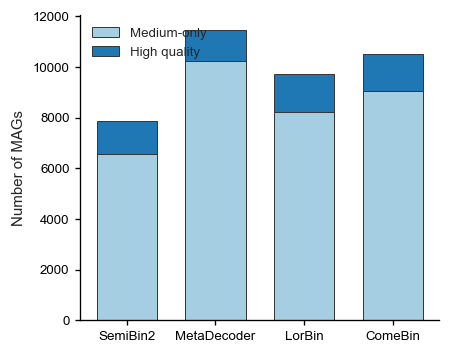

In [20]:
df = with_display_method(quality_counts)
x = np.arange(len(DISPLAY_METHODS))
medium_only = df['Medium_only_MAGs'].to_numpy()
high = df['High_quality_MAGs'].to_numpy()
fig, ax = plt.subplots(figsize=(3.8, 3.0))
ax.bar(x, medium_only, width=0.68, label='Medium-only',
       color=DISPLAY_STACK_COLORS['Medium-only'], edgecolor='#373737', linewidth=0.6)
ax.bar(x, high, width=0.68, bottom=medium_only, label='High quality',
       color=DISPLAY_STACK_COLORS['High quality'], edgecolor='#373737', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(DISPLAY_METHODS, rotation=0, ha='center', fontstyle='normal')
ax.set_ylabel('Number of MAGs')
style_axis(ax)
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
plt.show()

<ipython-input-19-75f213540576>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Method', y='Medium_or_better_percent_of_checked_bins',


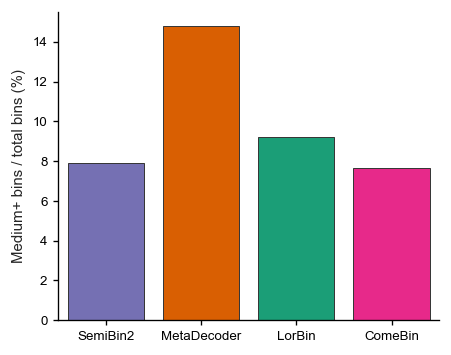

In [19]:
df = with_display_method(quality_counts)
fig, ax = plt.subplots(figsize=(3.8, 3.0))
sns.barplot(data=df, x='Method', y='Medium_or_better_percent_of_checked_bins',
            order=DISPLAY_METHODS, palette=DISPLAY_PALETTE, saturation=1,
            edgecolor='#373737', linewidth=0.6, ax=ax)
ax.set_ylabel('Medium+ bins / total bins (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
style_axis(ax)
fig.tight_layout()
plt.show()

In [18]:
def make_ms_box(df, quality_flag, metric, ylabel, title):
    plot_df = with_display_method(df[df[quality_flag]].copy())
    fig, ax = plt.subplots(figsize=(3.8, 3.0))
    sns.boxplot(data=plot_df, x='Method', y=metric, order=DISPLAY_METHODS,
                palette=DISPLAY_PALETTE, saturation=1, width=0.55,
                linewidth=0.8, showfliers=False, ax=ax)
    for patch in ax.patches:
        patch.set_edgecolor('#373737')
        patch.set_linewidth(0.8)
    for line in ax.lines:
        line.set_color('#373737')
        line.set_linewidth(0.8)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=0)
    style_axis(ax)
    fig.tight_layout()
    return fig

<ipython-input-18-6aa6a2b9e313>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Method', y=metric, order=DISPLAY_METHODS,


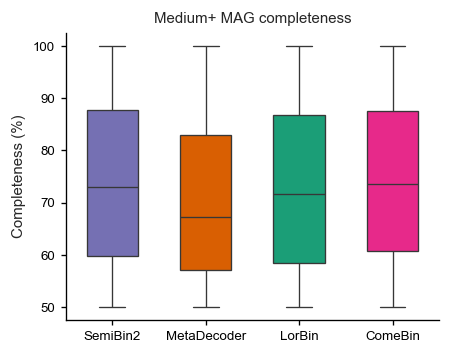

In [21]:
fig = make_ms_box(all_bins, 'Medium_or_better', 'Completeness', 'Completeness (%)', 'Medium+ MAG completeness')
plt.show()

<ipython-input-18-6aa6a2b9e313>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Method', y=metric, order=DISPLAY_METHODS,


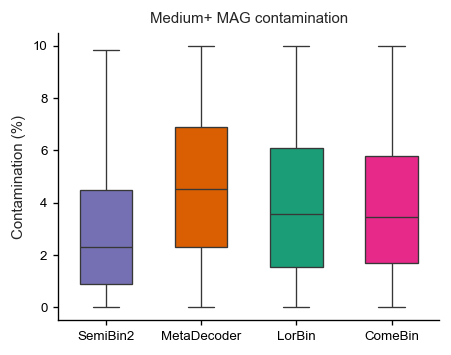

In [22]:
fig = make_ms_box(all_bins, 'Medium_or_better', 'Contamination', 'Contamination (%)', 'Medium+ MAG contamination')
plt.show()

<ipython-input-18-6aa6a2b9e313>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Method', y=metric, order=DISPLAY_METHODS,


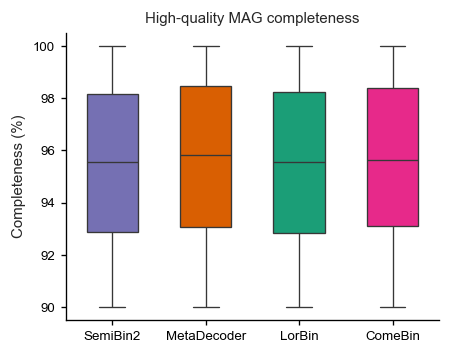

In [23]:
fig = make_ms_box(all_bins, 'High_quality', 'Completeness', 'Completeness (%)', 'High-quality MAG completeness')
plt.show()

<ipython-input-18-6aa6a2b9e313>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Method', y=metric, order=DISPLAY_METHODS,


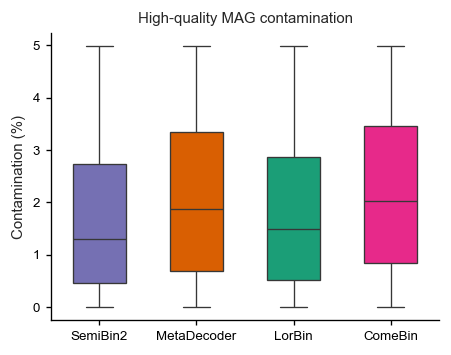

In [24]:
fig = make_ms_box(all_bins, 'High_quality', 'Contamination', 'Contamination (%)', 'High-quality MAG contamination')
plt.show()